<a href="https://colab.research.google.com/github/immischein/ML-bandgap/blob/victor_code/final_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Code

### Import Packages

In [1]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 5.1 MB/s eta 0:00:00


In [1]:

from google.colab import drive

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer
from sklearn.preprocessing import OneHotEncoder

#import category_encoders as ce

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from tqdm import tqdm



### Load Datasets

In [2]:
drive.mount('/content/drive')

# load original dataset (all materials)
df_full = pd.read_csv('/content/drive/MyDrive/Project Documents ML-CMT/bandgap_dataset_full.csv')
# load balanced dataset (downsampled low bangap materials)
df_balanced= pd.read_csv('/content/drive/MyDrive/Project Documents ML-CMT/bandgap_dataset_balanced.csv')

Mounted at /content/drive


In [3]:
df_full.head()

,material_id,band_gap,density,volume,a,b,c,alpha,beta,gamma,...,atomic_radius_range,std_atomic_radius,max_atomic_radius,min_atomic_radius,avg_boiling_point,boiling_point_range,std_boiling_point,max_boiling_point,min_boiling_point,number_of_elements
0,mp-11107,3.5226,9.109130,91.511224,4.095487,4.095489,6.299882,90.000000,90.000000,120.000000,...,1.950000,0.749099,2.55,0.600000,2179.880000,3573.000000,1328.258087,3663.20,90.200000,2
1,mp-32800,2.2962,6.535149,1118.407852,14.997851,14.997851,14.997851,144.742139,144.742139,50.718963,...,2.475000,0.846375,2.95,0.475000,2430.948000,3573.000000,1325.633733,4290.87,717.870000,2
2,mp-977351,3.0275,5.562971,328.464893,7.619779,7.619773,7.875664,118.930903,61.069136,119.999942,...,2.475000,0.846375,2.95,0.475000,2430.948000,3573.000000,1325.633733,4290.87,717.870000,2
3,mp-867311,0.0794,7.997421,122.518406,5.574922,5.574922,5.574922,60.000000,60.000000,60.000000,...,4.722697,1.569947,4.95,0.227303,3093.981638,6325.091812,2284.429504,7269.00,943.908188,3
4,mp-1183115,4.1024,8.728230,57.451413,3.858634,3.858634,3.858634,90.000000,90.000000,90.000000,...,3.248739,1.197316,3.80,0.551261,2752.463930,6365.000000,2164.271701,6455.20,90.200000,3


0         5
1        40
2        10
3         4
4         5
         ..
81993     4
81994     4
81995     8
81996     4
81997     4
Name: n_atoms, Length: 81998, dtype: int64


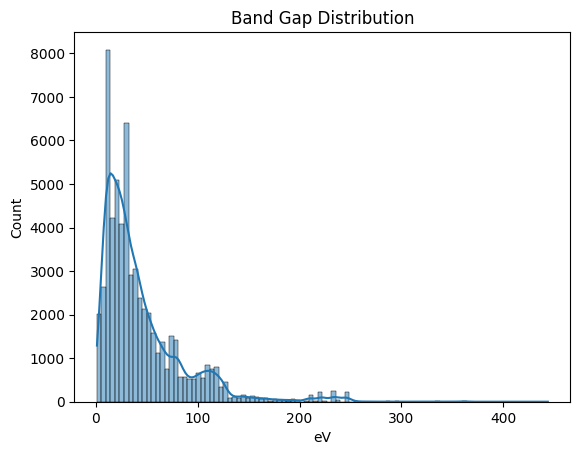

In [6]:
# prompt: extract n_atoms from df_full

n_atoms = df_full['n_atoms']
print(n_atoms)
sns.histplot(df_balanced["n_atoms"], bins=100, kde=True)
plt.title("Band Gap Distribution")
plt.xlabel("eV")
plt.show()

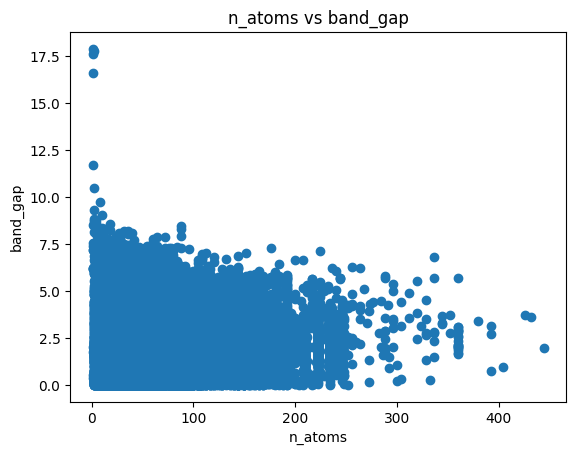

In [7]:
# prompt: plot the n_atoms on x axis and the band_gap on y axis

import matplotlib.pyplot as plt
plt.scatter(df_full['n_atoms'], df_full['band_gap'])
plt.xlabel('n_atoms')
plt.ylabel('band_gap')
plt.title('n_atoms vs band_gap')
plt.show()

In [8]:
# prompt: calculate spearman correlation between n_atoms and Band_gap

correlation_spearman = df_full['n_atoms'].corr(df_full['band_gap'], method='spearman')
print(f"Spearman correlation between n_atoms and band_gap: {correlation_spearman}")

Spearman correlation between n_atoms and band_gap: 0.17683410781641656


In [10]:
# prompt: compute correlation matrix between all parameters in df_full
df = df_full.drop(columns=['material_id'])
correlation_matrix = df.corr()
correlation_matrix

,band_gap,density,volume,a,b,c,alpha,beta,gamma,n_atoms,...,atomic_radius_range,std_atomic_radius,max_atomic_radius,min_atomic_radius,avg_boiling_point,boiling_point_range,std_boiling_point,max_boiling_point,min_boiling_point,number_of_elements
band_gap,1.000000,-0.178732,0.040918,0.050975,0.013586,0.010295,-0.052236,-0.019509,0.036687,0.147730,...,-0.017339,0.003005,-0.008352,0.093492,-0.126508,-0.091632,-0.089923,-0.110830,-0.248335,0.086466
density,-0.178732,1.000000,-0.246552,-0.210669,-0.183959,-0.099036,-0.041365,-0.070717,-0.052176,-0.252225,...,0.051506,0.046527,0.073764,0.258690,0.188944,0.135538,0.129152,0.145786,0.134287,-0.193938
volume,0.040918,-0.246552,1.000000,0.604012,0.587553,0.551553,0.068716,0.093295,0.192370,0.789210,...,0.200727,0.195522,0.188822,-0.072794,0.110511,0.130405,0.138460,0.135249,0.064803,0.216173
a,0.050975,-0.210669,0.604012,1.000000,0.488100,0.119228,-0.061346,0.011344,-0.019264,0.542072,...,0.180540,0.176075,0.173580,-0.024413,0.078163,0.096981,0.102607,0.099842,0.038673,0.184193
b,0.013586,-0.183959,0.587553,0.488100,1.000000,0.162951,0.046754,0.032737,-0.056646,0.480047,...,0.099388,0.091139,0.093126,-0.040067,0.028778,0.030406,0.034162,0.035653,0.067976,0.101482
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
boiling_point_range,-0.091632,0.135538,0.130405,0.096981,0.030406,0.130188,0.017895,0.005130,0.095764,0.240472,...,0.644327,0.653439,0.635495,0.088293,0.945799,1.000000,0.998408,0.996964,-0.019051,0.616835
std_boiling_point,-0.089923,0.129152,0.138460,0.102607,0.034162,0.136694,0.017571,0.005040,0.099530,0.247445,...,0.649783,0.658721,0.640004,0.079481,0.949121,0.998408,1.000000,0.996578,-0.003587,0.626081
max_boiling_point,-0.110830,0.145786,0.135249,0.099842,0.035653,0.138858,0.022071,0.005961,0.094595,0.224948,...,0.646954,0.651025,0.636285,0.068911,0.954118,0.996964,0.996578,1.000000,0.058858,0.594675
min_boiling_point,-0.248335,0.134287,0.064803,0.038673,0.067976,0.113919,0.053978,0.010771,-0.013095,-0.194545,...,0.045647,-0.018751,0.021949,-0.246657,0.125672,-0.019051,-0.003587,0.058858,1.000000,-0.272242


Text(0.5, 1.0, 'Correlation Matrix')

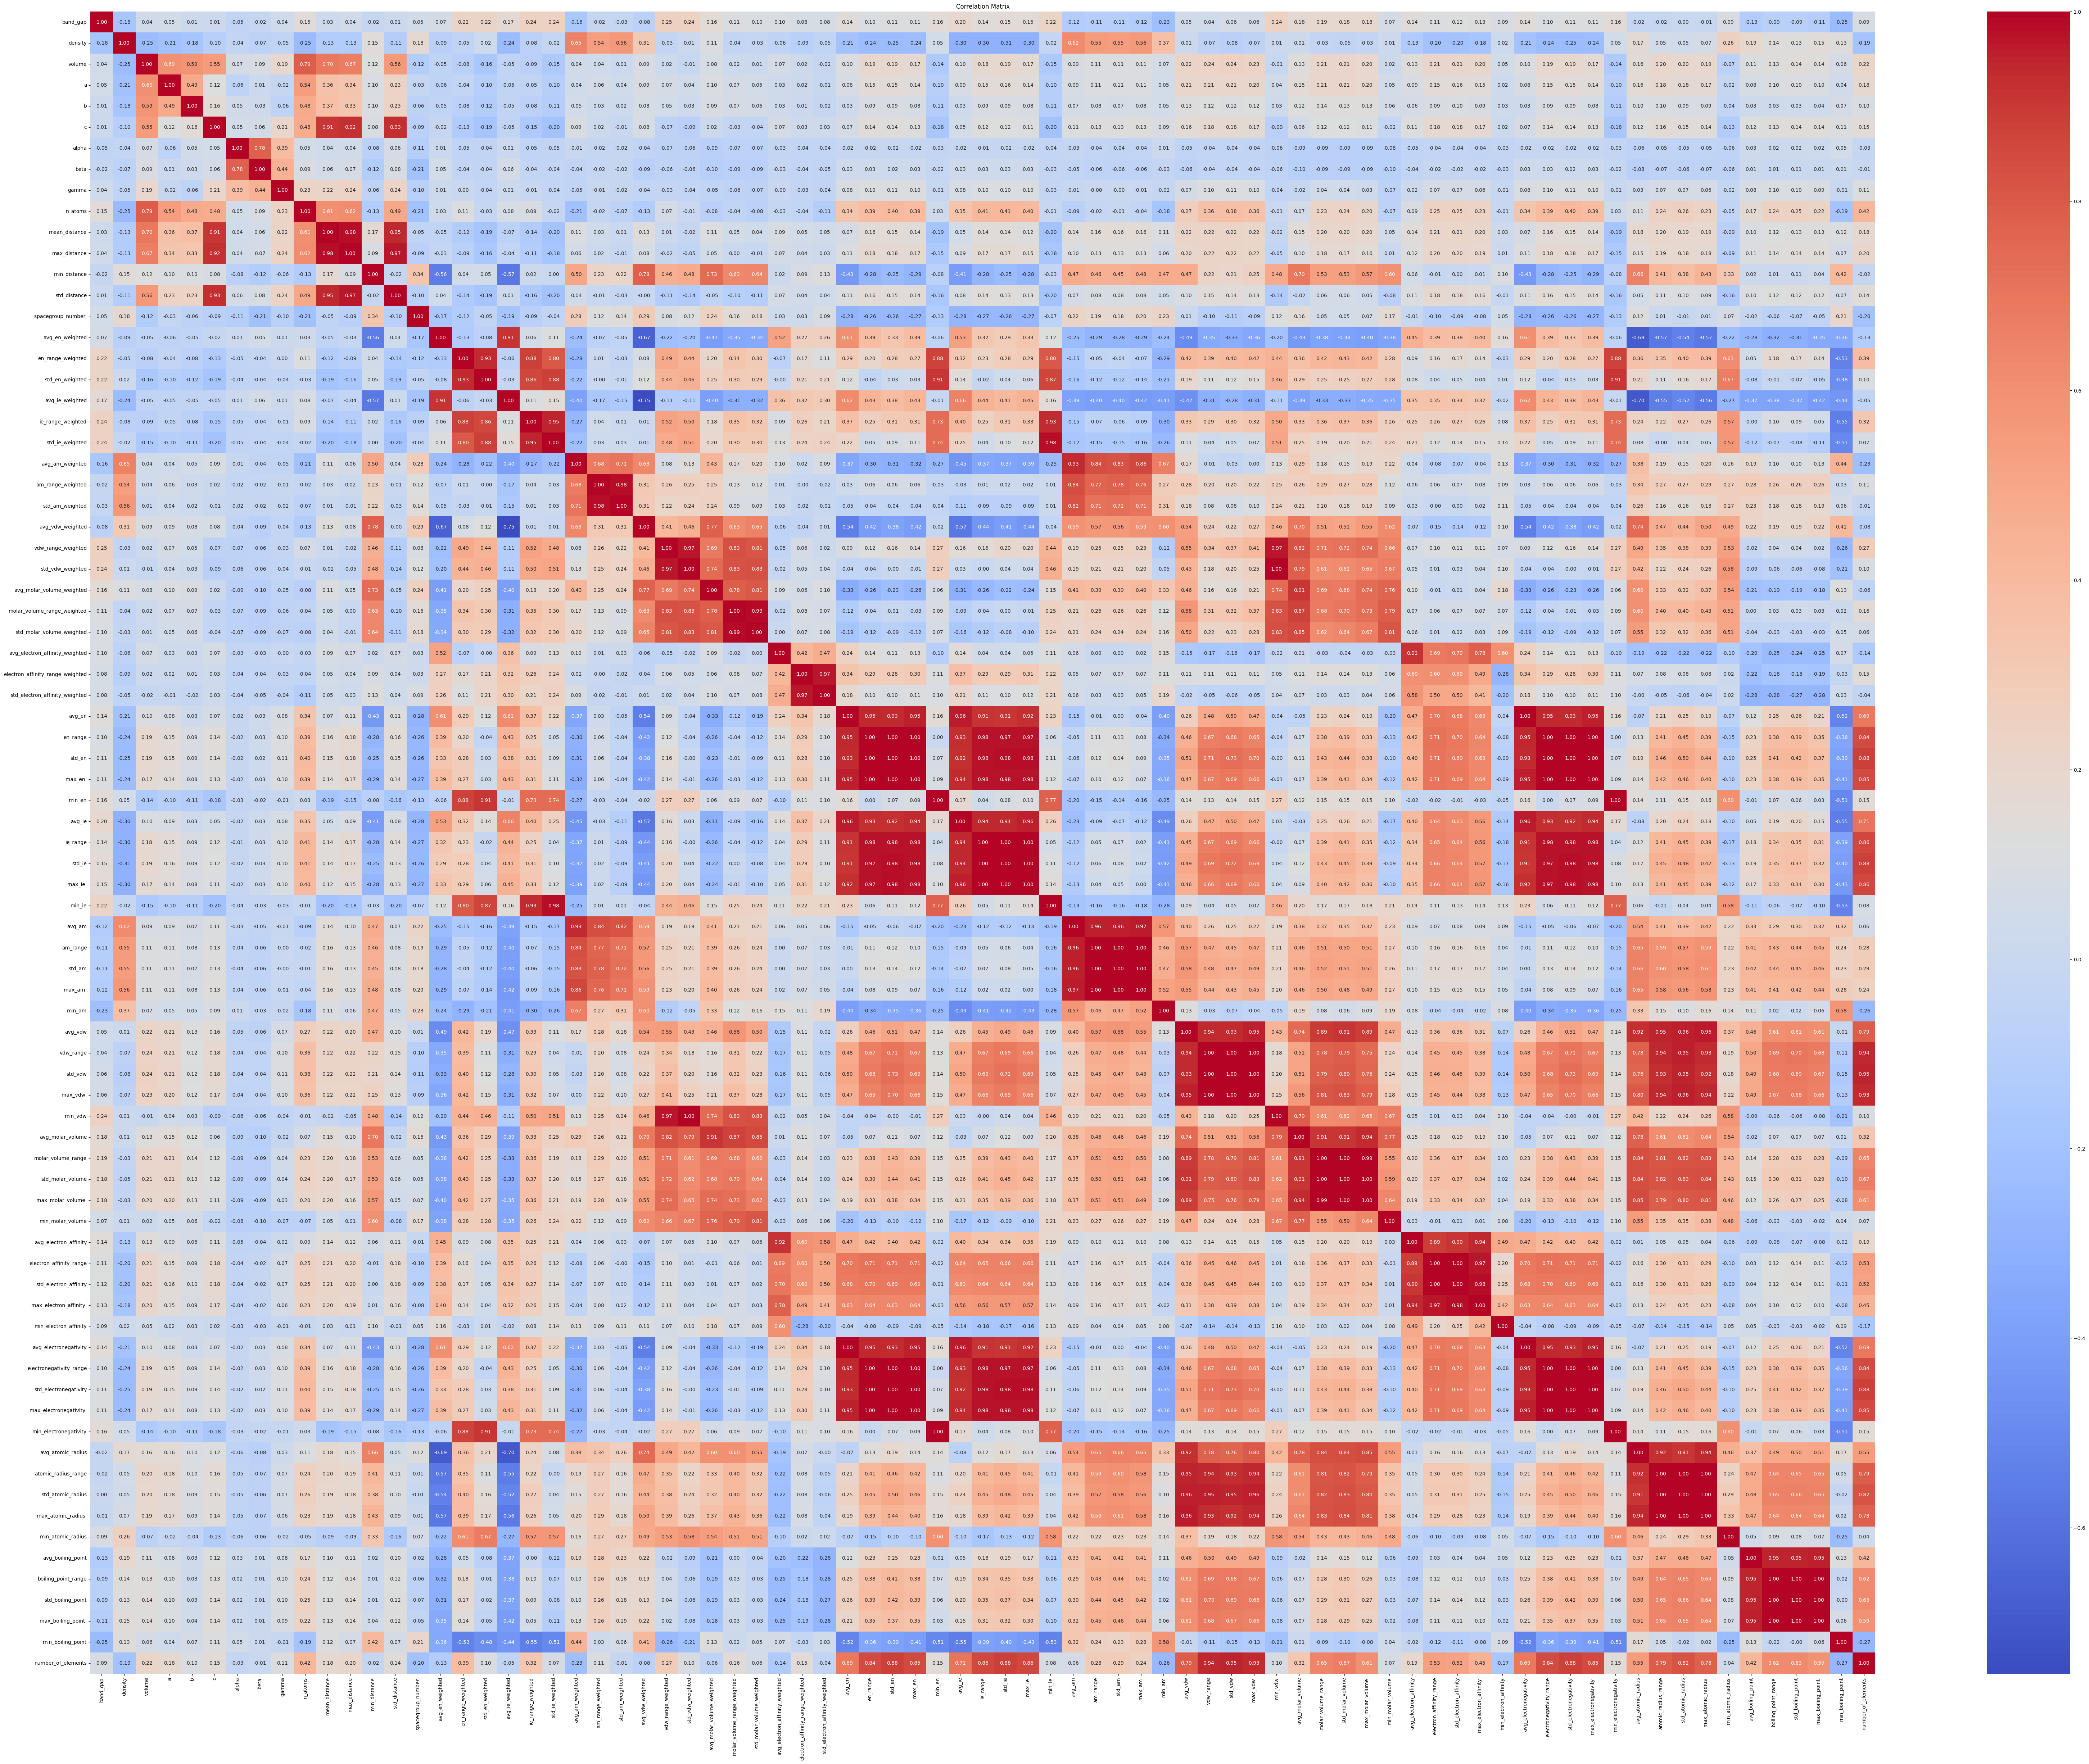

In [13]:
plt.figure(figsize=(80, 60))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")

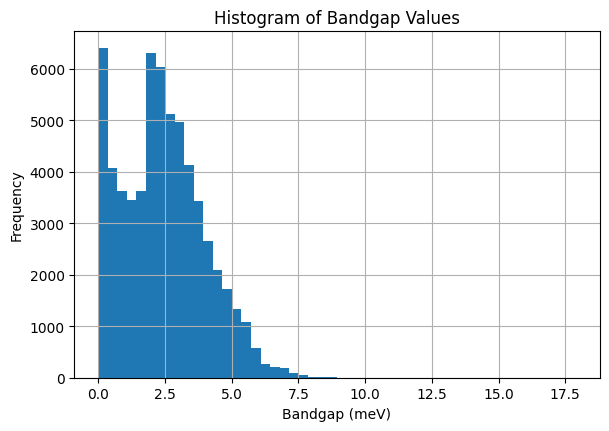

In [10]:
# plot a histogram of bandgap values
df_balanced["band_gap"].hist(bins=50, figsize=(6, 4))
plt.tight_layout()
plt.title("Histogram of Bandgap Values")
plt.xlabel("Bandgap (meV)")
plt.ylabel("Frequency")
plt.show()

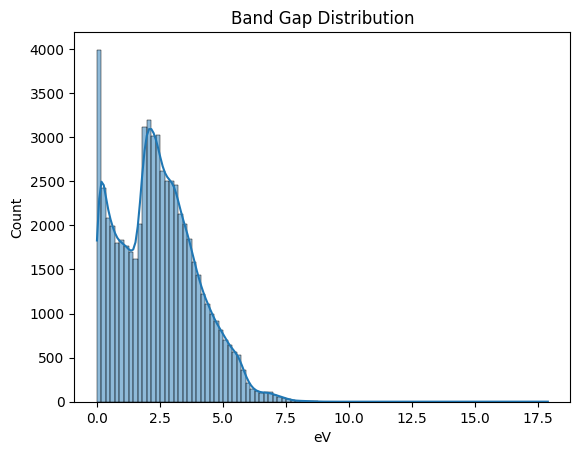

In [12]:
sns.histplot(df_balanced["band_gap"], bins=100, kde=True)
plt.title("Band Gap Distribution")
plt.xlabel("eV")
plt.show()

In [16]:
print("Mean ", np.mean(df_balanced["band_gap"]))
print("std ", np.std(df_balanced["band_gap"]))
print("length ", len(df_balanced["band_gap"]))

Mean  2.4303718843918025
std  1.5540968827611106
length  61540


### Data cleaning step

In [ ]:
def initial_data_cleaning(df, target_col='band_gap', id_col='material_id', corr_thresh=0.95):
    df = df.copy()

    # Drop identifier
    if id_col in df.columns:
        df = df.drop(columns=id_col)

    # Separate target
    X = df.drop(columns=target_col)
    y = df[target_col]

    # Split first (to avoid leakage)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Drop columns with >65% missing
    missing_frac = X_train.isnull().mean()
    drop_cols = missing_frac[missing_frac > 0.65].index.tolist()
    print(f"Dropping columns with >65% missing values: {drop_cols}")
    X_train = X_train.drop(columns=drop_cols)
    X_test = X_test.drop(columns=drop_cols)

    # Correlation-based feature dropping (on train set only)
    corr_matrix = X_train.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    to_drop = []
    for col in upper.columns:
        for row in upper.index:
            if upper.loc[row, col] > corr_thresh:
                if row in to_drop or col in to_drop:
                    continue
                target_corr = X_train.corrwith(y_train)
                drop = row if target_corr[row] < target_corr[col] else col
                to_drop.append(drop)

    print(f"Dropping correlated features: {to_drop}")
    X_train = X_train.drop(columns=to_drop)
    X_test = X_test.drop(columns=to_drop)

    return X_train, X_test, y_train, y_test

### Preprocessing Pipeline

In [ ]:
class TargetEncoderWrapper(BaseEstimator, TransformerMixin):
    def __init__(self, column):
        self.column = column  # ✅ declared here, not in fit
        self.encoder_ = None  # ✅ trailing underscore: fitted object

    def fit(self, X, y):
        self.encoder_ = ce.TargetEncoder(cols=[self.column])
        self.encoder_.fit(X, y)
        return self

    def transform(self, X):
        return self.encoder_.transform(X)


In [ ]:
def build_preprocessor(numeric_cols, nonnumeric_cols, te_col='spacegroup_number '):
    if te_col in numeric_cols:
        numeric_cols = [col for col in numeric_cols if col != te_col]

    num_pipeline = make_pipeline(
        SimpleImputer(strategy='mean'),
        StandardScaler()
    )

    # cat_pipeline = make_pipeline(TargetEncoderWrapper())
    cat_pipeline = make_pipeline(TargetEncoderWrapper(column='spacegroup_number '))

    nonnumeric_pipeline = make_pipeline(
        SimpleImputer(strategy="most_frequent"),
        OneHotEncoder(handle_unknown="ignore")
    )

    preprocessor = make_column_transformer(
        (num_pipeline, numeric_cols),
        (cat_pipeline, [te_col]),
        (nonnumeric_pipeline, nonnumeric_cols)
    )

    return preprocessor


### CV Training Pipeline

In [ ]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def run_pipeline_with_cv(X, y, model_dict, cv=5):
    results = []

    te_col = 'spacegroup_number '
    numeric_cols = X.select_dtypes(include=np.number).columns.tolist()
    nonnumeric_cols = X.select_dtypes(exclude=np.number).columns.tolist()
    if te_col in numeric_cols:
        numeric_cols.remove(te_col)

    for name, model in model_dict.items():
        print(f"\nRunning CV for model: {name}")

        # Build a fresh pipeline for each model
        pipeline = make_pipeline(
            build_preprocessor(numeric_cols, nonnumeric_cols, te_col=te_col),
            model
        )

        scores = cross_validate(
            pipeline, X, y, cv=cv,
            scoring={
                'mae': 'neg_mean_absolute_error',
                'r2': 'r2',
                'rmse': make_scorer(rmse, greater_is_better=False)
            },
            return_train_score=False
        )

        results.append({
            'Model': name,
            'MAE (mean)': -np.mean(scores['test_mae']),
            'RMSE (mean)': -np.mean(scores['test_rmse']),
            'R² (mean)': np.mean(scores['test_r2'])
        })

    return pd.DataFrame(results)

### Evaluation Pipeline

In [ ]:
def run_final_test_evaluation(X_train, X_test, y_train, y_test, model_dict):
    final_results = []
    trained_pipelines = []

    # Detect column types
    te_col = 'spacegroup_number '
    numeric_cols = X_train.select_dtypes(include=np.number).columns.tolist()
    nonnumeric_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

    # Remove target-encoded column from numeric
    if te_col in numeric_cols:
        numeric_cols.remove(te_col)

    for name, model in model_dict.items():
        print(f"\nTraining final model: {name}")

        # Build preprocessor and pipeline
        preprocessor = build_preprocessor(numeric_cols, nonnumeric_cols, te_col=te_col)
        pipeline = make_pipeline(preprocessor, model)

        # Fit on full training set
        pipeline.fit(X_train, y_train)

        # Evaluate on test set
        y_pred = pipeline.predict(X_test)
        mae = mean_absolute_error(y_test, y_pred)
        rmse_ = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

        final_results.append({
            'Model': name,
            'Test MAE': mae,
            'Test RMSE': rmse_,
            'Test R²': r2
        })

        trained_pipelines.append((name, pipeline))

    return pd.DataFrame(final_results), dict(trained_pipelines)


### Neural Network training

In [ ]:
class BandgapNet(nn.Module):
    def __init__(self, input_dim):
        super(BandgapNet, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)


In [ ]:
def train_torch_model(X_train, X_test, y_train, y_test, num_epochs=100, batch_size=64, lr=1e-3, print_every=10):
    te_col = 'spacegroup_number '
    numeric_cols = X_train.select_dtypes(include=np.number).columns.tolist()
    nonnumeric_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

    if te_col in numeric_cols:
        numeric_cols.remove(te_col)

    # Step 1: Preprocess
    preprocessor = build_preprocessor(numeric_cols, nonnumeric_cols, te_col)
    X_train_proc = preprocessor.fit_transform(X_train, y_train)
    X_test_proc = preprocessor.transform(X_test)

    # Step 2: Convert to tensors
    X_train_tensor = torch.tensor(X_train_proc.astype(np.float32))
    y_train_tensor = torch.tensor(y_train.values.astype(np.float32)).unsqueeze(1)
    X_test_tensor = torch.tensor(X_test_proc.astype(np.float32))
    y_test_tensor = torch.tensor(y_test.values.astype(np.float32)).unsqueeze(1)

    # Step 3: Create dataset and dataloader
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    # Step 4: Initialize model, loss, optimizer
    model = BandgapNet(input_dim=X_train_tensor.shape[1])
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    val_losses = []

    # Step 5: Train loop with tqdm
    for epoch in tqdm(range(num_epochs), desc="Training Epochs"):
        model.train()
        epoch_train_loss = 0.0

        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            epoch_train_loss += loss.item() * X_batch.size(0)

        avg_train_loss = epoch_train_loss / len(train_loader.dataset)
        train_losses.append(avg_train_loss)

        # Validation loss
        model.eval()
        with torch.no_grad():
            val_pred = model(X_test_tensor)
            val_loss = criterion(val_pred, y_test_tensor).item()
            val_losses.append(val_loss)

        # Optional print
        if (epoch + 1) % print_every == 0 or epoch == 0 or epoch == num_epochs - 1:
            print(f"Epoch {epoch+1:3d} | Train Loss: {avg_train_loss:.5f} | Val Loss: {val_loss:.5f}")

    # Step 6: Final Evaluation
    model.eval()
    with torch.no_grad():
        y_pred = model(X_test_tensor).squeeze().numpy()
        y_true = y_test_tensor.squeeze().numpy()

    mae = mean_absolute_error(y_true, y_pred)
    rmse_ = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    # Step 7: Plot learning curves
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.title('PyTorch Neural Network Learning Curves')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return {
        'Model': 'PyTorch DNN',
        'Test MAE': mae,
        'Test RMSE': rmse_,
        'Test R²': r2
    }, model, preprocessor

## Models

In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "MLP": MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, early_stopping=True, random_state=42)
}

# Modeling Experiment 1: What is the influence of downsampling the low bandgap data?

#### Full dataset

In [ ]:
# Clean data
X_train_full, X_test_full, y_train_full, y_test_full = initial_data_cleaning(df_full, target_col='band_gap')

Dropping columns with >65% missing values: []
Dropping correlated features: ['mean_distance', 'std_distance', 'std_am_weighted', 'std_vdw_weighted', 'std_molar_volume_weighted', 'electron_affinity_range_weighted', 'en_range', 'max_en ', 'avg_en', 'std_en', 'ie_range', 'max_ie ', 'min_ie', 'avg_am', 'am_range', 'max_am ', 'vdw_range', 'avg_vdw', 'max_vdw ', 'min_vdw', 'std_molar_volume', 'max_molar_volume ', 'electron_affinity_range', 'std_electron_affinity', 'avg_electronegativity', 'electronegativity_range', 'std_electronegativity', 'max_electronegativity ', 'min_electronegativity', 'atomic_radius_range', 'max_atomic_radius ', 'boiling_point_range', 'avg_boiling_point', 'max_boiling_point ']


In [ ]:
# CV training using full training set
cv_results_full = run_pipeline_with_cv(X_train_full, y_train_full, models, cv=5)
display(cv_results_full)


Running CV for model: Linear Regression

Running CV for model: Random Forest

Running CV for model: MLP


,Model,MAE (mean),RMSE (mean),R² (mean)
0,Linear Regression,1.042909,1.310815,0.289514
1,Random Forest,0.666381,0.935851,0.637800
2,MLP,0.797147,1.062212,0.533421


In [ ]:
# Train on full train set, evaluate on test
test_results_full, trained_models = run_final_test_evaluation(X_train_full, X_test_full, y_train_full, y_test_full, models)
display(test_results_full)


Training final model: Linear Regression

Training final model: Random Forest

Training final model: MLP


,Model,Test MAE,Test RMSE,Test R²
0,Linear Regression,1.042296,1.312468,0.286370
1,Random Forest,0.636155,0.897099,0.666592
2,MLP,0.772779,1.034674,0.556491


Training Epochs:   1%|          | 1/100 [00:01<02:53,  1.76s/it]

Epoch   1 | Train Loss: 1.66942 | Val Loss: 1.45437


Training Epochs:  10%|█         | 10/100 [00:20<03:21,  2.24s/it]

Epoch  10 | Train Loss: 1.09162 | Val Loss: 1.12217


Training Epochs:  20%|██        | 20/100 [00:38<02:29,  1.87s/it]

...

Epoch  80 | Train Loss: 0.73076 | Val Loss: 1.01431


Training Epochs:  90%|█████████ | 90/100 [02:53<00:19,  1.90s/it]

Epoch  90 | Train Loss: 0.70696 | Val Loss: 1.02870


Training Epochs: 100%|██████████| 100/100 [03:13<00:00,  1.93s/it]

Epoch 100 | Train Loss: 0.69453 | Val Loss: 1.01237


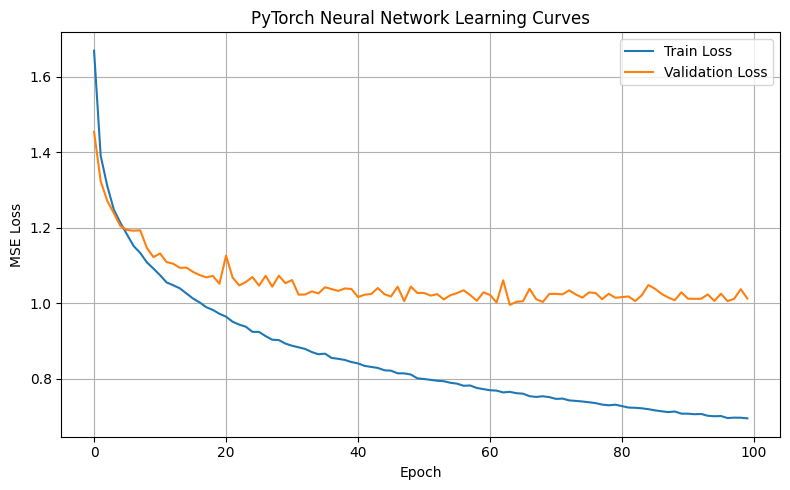

,Model,Test MAE,Test RMSE,Test R²
0,PyTorch DNN,0.746028,1.006164,0.580595


In [ ]:
torch_result_full, torch_model_full, torch_preprocessor_full = train_torch_model(
    X_train_full, X_test_full, y_train_full, y_test_full,
    num_epochs=100, lr=1e-3, batch_size=64, print_every=10
)

display(pd.DataFrame([torch_result_full]))

#### Balanced dataset

In [ ]:
# Clean data
X_train_balanced, X_test_balanced, y_train_balanced, y_test_balanced = initial_data_cleaning(df_balanced, target_col='band_gap')

Dropping columns with >65% missing values: []
Dropping correlated features: ['mean_distance', 'std_distance', 'std_am_weighted', 'std_vdw_weighted', 'std_molar_volume_weighted', 'electron_affinity_range_weighted', 'en_range', 'max_en ', 'avg_en', 'std_en', 'ie_range', 'max_ie ', 'min_ie', 'avg_am', 'am_range', 'max_am ', 'vdw_range', 'avg_vdw', 'max_vdw ', 'min_vdw', 'std_molar_volume', 'max_molar_volume ', 'electron_affinity_range', 'std_electron_affinity', 'avg_electronegativity', 'electronegativity_range', 'std_electronegativity', 'max_electronegativity ', 'min_electronegativity', 'atomic_radius_range', 'max_atomic_radius ', 'avg_boiling_point', 'boiling_point_range', 'max_boiling_point ']


In [ ]:
# For CV we use full training set
cv_results_balanced = run_pipeline_with_cv(X_train_balanced, y_train_balanced, models, cv=5)
display(cv_results_balanced)


Running CV for model: Linear Regression

Running CV for model: Random Forest

Running CV for model: MLP


,Model,MAE (mean),RMSE (mean),R² (mean)
0,Linear Regression,1.024386,1.293052,0.309979
1,Random Forest,0.660474,0.925348,0.646537
2,MLP,0.781334,1.039648,0.553800


In [ ]:
# Train on full train set, evaluate on test
test_results_balanced, trained_models = run_final_test_evaluation(X_train_balanced, X_test_balanced, y_train_balanced, y_test_balanced, models)
display(test_results_balanced)


Training final model: Linear Regression

Training final model: Random Forest

Training final model: MLP


,Model,Test MAE,Test RMSE,Test R²
0,Linear Regression,1.022686,1.285546,0.306373
1,Random Forest,0.635946,0.894006,0.664547
2,MLP,0.767046,1.020341,0.563040


Training Epochs:   1%|          | 1/100 [00:01<02:11,  1.33s/it]

Epoch   1 | Train Loss: 1.72931 | Val Loss: 1.46983


Training Epochs:  10%|█         | 10/100 [00:14<02:13,  1.48s/it]

Epoch  10 | Train Loss: 1.06771 | Val Loss: 1.14256


Training Epochs:  20%|██        | 20/100 [00:29<01:55,  1.45s/it]

...

Epoch  80 | Train Loss: 0.67213 | Val Loss: 0.98701


Training Epochs:  90%|█████████ | 90/100 [02:14<00:16,  1.62s/it]

Epoch  90 | Train Loss: 0.65484 | Val Loss: 1.00229


Training Epochs: 100%|██████████| 100/100 [02:29<00:00,  1.49s/it]

Epoch 100 | Train Loss: 0.63370 | Val Loss: 1.00814


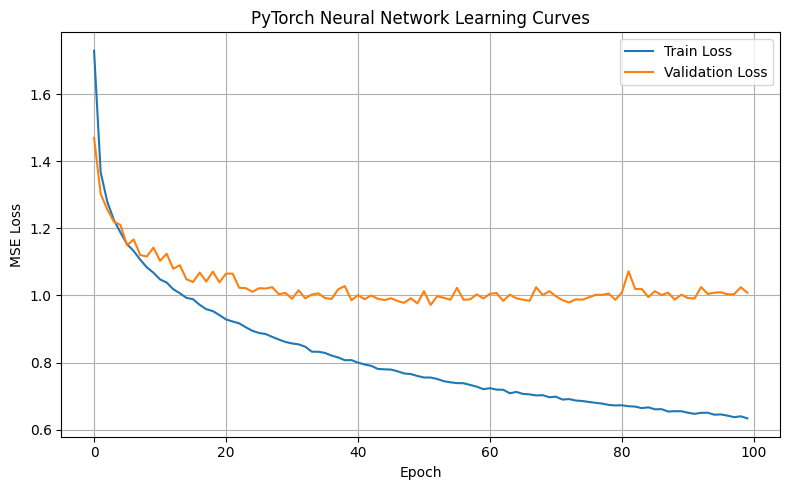

,Model,Test MAE,Test RMSE,Test R²
0,PyTorch DNN,0.737275,1.004064,0.576871


In [ ]:
torch_result_balanced, torch_model_balanced, torch_preprocessor_balanced= train_torch_model(
    X_train_balanced, X_test_balanced, y_train_balanced, y_test_balanced,
    num_epochs=100, lr=1e-3, batch_size=64, print_every=10
)

display(pd.DataFrame([torch_result_balanced]))

#### Result

In [ ]:
# turn results to dataframe
df_torch_full = pd.DataFrame([torch_result_full])
df_torch_balanced = pd.DataFrame([torch_result_balanced])

# Add column to indicate dataset
test_results_full['Dataset'] = 'Full'
df_torch_full['Dataset'] = 'Full'
test_results_balanced['Dataset'] = 'Balanced'
df_torch_balanced['Dataset'] = 'Balanced'

combined_results = pd.concat([
    test_results_full,
    df_torch_full,
    test_results_balanced,
    df_torch_balanced
], ignore_index=True)

combined_results = combined_results[['Model', 'Dataset', 'Test MAE', 'Test RMSE', 'Test R²']]

display(combined_results.sort_values(by=['Model', 'Dataset']))

,Model,Dataset,Test MAE,Test RMSE,Test R²
4,Linear Regression,Balanced,1.022686,1.285546,0.306373
0,Linear Regression,Full,1.042296,1.312468,0.286370
6,MLP,Balanced,0.767046,1.020341,0.563040
2,MLP,Full,0.772779,1.034674,0.556491
7,PyTorch DNN,Balanced,0.737275,1.004064,0.576871
3,PyTorch DNN,Full,0.746028,1.006164,0.580595
5,Random Forest,Balanced,0.635946,0.894006,0.664547
1,Random Forest,Full,0.636155,0.897099,0.666592


**Conclusion I)**:
Downsampling the materials with a low value for the bandgap (keeping only 50% of the materials with a bandgap in the region 0 to 1.75 meV) doesn't have a big influence on the model performance.
**Decision**: Keep the full dataset to have more samples (useful for deep networks).

**Conclusion II)**:
This experiment can be used for model selction as well. The best performing models that we will move forward with are **Random Forrest** and **PyTorch DNN**.

**Conclusion III)**:
Using a Deep NN (without hyperparameter optimization) does not have an evident advantage over a simpler MLP.



# Model Selection

In [ ]:
display(combined_results.sort_values(by=['Test MAE', 'Test R²']))

,Model,Dataset,Test MAE,Test RMSE,Test R²
5,Random Forest,Balanced,0.635946,0.894006,0.664547
1,Random Forest,Full,0.636155,0.897099,0.666592
7,PyTorch DNN,Balanced,0.737275,1.004064,0.576871
3,PyTorch DNN,Full,0.746028,1.006164,0.580595
6,MLP,Balanced,0.767046,1.020341,0.563040
2,MLP,Full,0.772779,1.034674,0.556491
4,Linear Regression,Balanced,1.022686,1.285546,0.306373
0,Linear Regression,Full,1.042296,1.312468,0.286370


**Result:** Move forward with **Random Forrest** and a **PyTorch DNN**.

# Experiment 2: How does the feature correlation drop off threshold influence the model performance?

In [ ]:
# Define thresholds
thresholds = [0.8, 0.9, 0.95, 1.0]

# Store cleaned data splits
cleaned_data_dict = {}

for thresh in thresholds:
    print(f"\n🧹 Preprocessing with corr threshold = {thresh}")
    X_train, X_test, y_train, y_test = initial_data_cleaning(df_full, target_col='band_gap', corr_thresh=thresh)
    cleaned_data_dict[thresh] = (X_train, X_test, y_train, y_test)



🧹 Preprocessing with corr threshold = 0.8
Dropping columns with >65% missing values: []
Dropping correlated features: ['c', 'mean_distance', 'std_distance', 'std_en_weighted', 'avg_en_weighted', 'en_range_weighted', 'ie_range_weighted', 'std_am_weighted', 'std_vdw_weighted', 'molar_volume_range_weighted', 'std_molar_volume_weighted', 'electron_affinity_range_weighted', 'en_range', 'std_en', 'max_en ', 'avg_en', 'ie_range', 'std_ie', 'max_ie ', 'min_ie', 'avg_am_weighted', 'avg_am', 'am_range', 'max_am ', 'vdw_range', 'avg_vdw', 'max_vdw ', 'min_vdw', 'avg_molar_volume', 'std_vdw', 'std_molar_volume', 'max_molar_volume ', 'avg_electron_affinity_weighted', 'electron_affinity_range', 'std_electron_affinity', 'max_electron_affinity ', 'avg_electronegativity', 'electronegativity_range', 'std_electronegativity', 'max_electronegativity ', 'min_electronegativity', 'avg_atomic_radius', 'atomic_radius_range', 'std_atomic_radius', 'max_atomic_radius ', 'avg_boiling_point', 'boiling_point_range',


🔧 Training PyTorch DNN with corr threshold = 0.8


Training Epochs:   1%|          | 1/100 [00:01<02:21,  1.43s/it]

Epoch   1 | Train Loss: 1.69384 | Val Loss: 1.53743


Training Epochs:  10%|█         | 10/100 [00:18<02:40,  1.78s/it]

Epoch  10 | Train Loss: 1.11932 | Val Loss: 1.18888


...

Epoch  80 | Train Loss: 0.77109 | Val Loss: 1.08034


Training Epochs:  90%|█████████ | 90/100 [02:08<00:13,  1.34s/it]

Epoch  90 | Train Loss: 0.75737 | Val Loss: 1.07152


Training Epochs: 100%|██████████| 100/100 [02:22<00:00,  1.43s/it]

Epoch 100 | Train Loss: 0.74558 | Val Loss: 1.07590


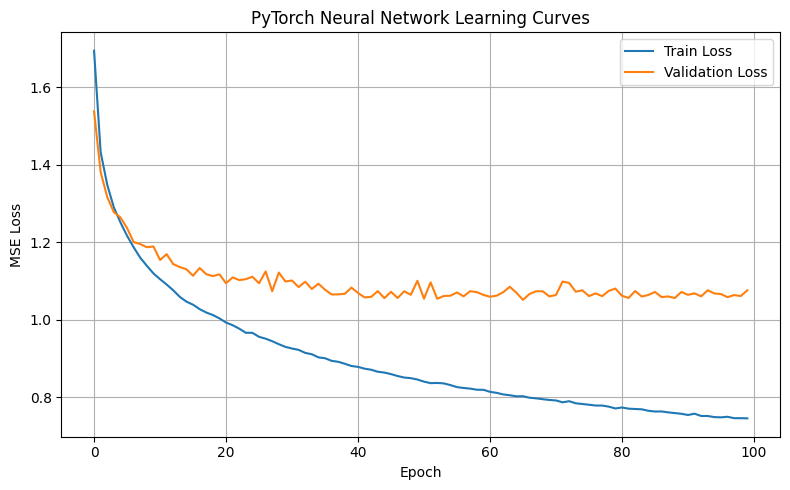


🔧 Training PyTorch DNN with corr threshold = 0.9


Training Epochs:   1%|          | 1/100 [00:01<02:42,  1.64s/it]

Epoch   1 | Train Loss: 1.71369 | Val Loss: 1.49292


Training Epochs:  10%|█         | 10/100 [00:14<02:09,  1.44s/it]

Epoch  10 | Train Loss: 1.10829 | Val Loss: 1.15707


...

Epoch  80 | Train Loss: 0.75250 | Val Loss: 1.07069


Training Epochs:  90%|█████████ | 90/100 [02:03<00:14,  1.48s/it]

Epoch  90 | Train Loss: 0.73605 | Val Loss: 1.07811


Training Epochs: 100%|██████████| 100/100 [02:17<00:00,  1.37s/it]

Epoch 100 | Train Loss: 0.72275 | Val Loss: 1.06047


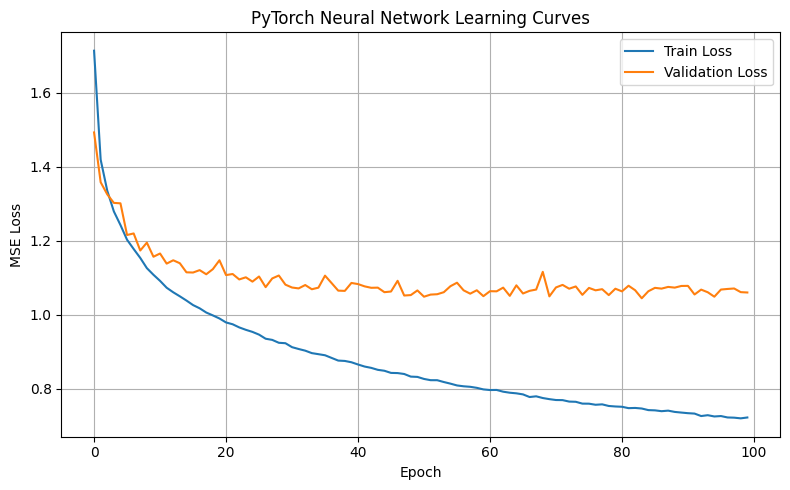


🔧 Training PyTorch DNN with corr threshold = 0.95


Training Epochs:   1%|          | 1/100 [00:01<02:08,  1.30s/it]

Epoch   1 | Train Loss: 1.65257 | Val Loss: 1.45191


Training Epochs:  10%|█         | 10/100 [00:13<02:03,  1.37s/it]

Epoch  10 | Train Loss: 1.08720 | Val Loss: 1.17042


...

Epoch  80 | Train Loss: 0.72229 | Val Loss: 1.03613


Training Epochs:  90%|█████████ | 90/100 [02:05<00:13,  1.35s/it]

Epoch  90 | Train Loss: 0.70194 | Val Loss: 1.03310


Training Epochs: 100%|██████████| 100/100 [02:19<00:00,  1.40s/it]

Epoch 100 | Train Loss: 0.68937 | Val Loss: 1.03473


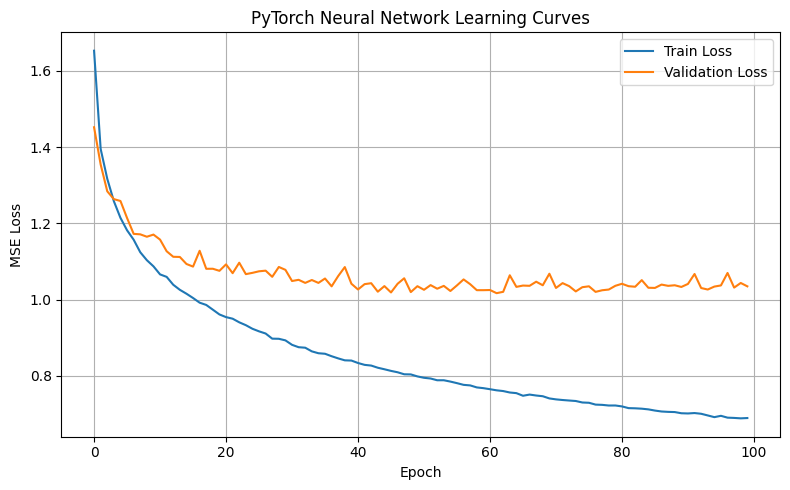


🔧 Training PyTorch DNN with corr threshold = 1.0


Training Epochs:   1%|          | 1/100 [00:01<02:53,  1.75s/it]

Epoch   1 | Train Loss: 1.64803 | Val Loss: 1.46185


Training Epochs:  10%|█         | 10/100 [00:15<02:20,  1.56s/it]

Epoch  10 | Train Loss: 1.09839 | Val Loss: 1.19696


...

Epoch  80 | Train Loss: 0.71526 | Val Loss: 1.00126


Training Epochs:  90%|█████████ | 90/100 [02:11<00:15,  1.59s/it]

Epoch  90 | Train Loss: 0.69675 | Val Loss: 1.02789


Training Epochs: 100%|██████████| 100/100 [02:25<00:00,  1.46s/it]

Epoch 100 | Train Loss: 0.67958 | Val Loss: 1.02964


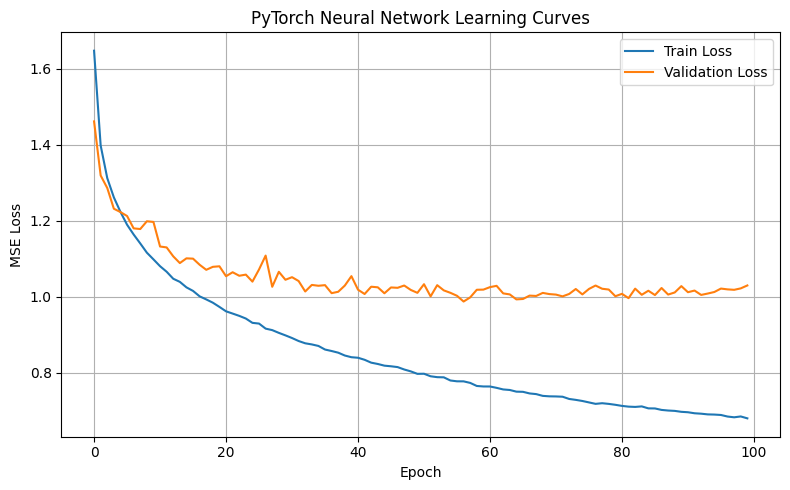

In [ ]:
experiment2_results = []

for thresh, (X_train, X_test, y_train, y_test) in cleaned_data_dict.items():
    print(f"\n🔧 Training PyTorch DNN with corr threshold = {thresh}")
    result, _, _ = train_torch_model(X_train, X_test, y_train, y_test, num_epochs=100, lr=1e-3)
    result['Corr Threshold'] = thresh
    experiment2_results.append(result)


### Result

In [ ]:
df_experiment2 = pd.DataFrame(experiment2_results)
df_experiment2 = df_experiment2[['Corr Threshold', 'Model', 'Test MAE', 'Test RMSE', 'Test R²']]
display(df_experiment2.sort_values(by='Corr Threshold'))

,Corr Threshold,Model,Test MAE,Test RMSE,Test R²
0,0.80,PyTorch DNN,0.769608,1.037254,0.554276
1,0.90,PyTorch DNN,0.759730,1.029793,0.560665
2,0.95,PyTorch DNN,0.741938,1.017216,0.571331
3,1.00,PyTorch DNN,0.754541,1.014711,0.573439


**Conclusion**: On a DNN the dropping of correlated features seems to have no strong effect on the performance, however dropping features will be computationally very benefitial for Random Forrests.

# Experiment 3: Drop categorical features (only `'spacegroup'` in our case)

In [ ]:
# Cleaned full dataset with corr threshold 0.95 (default)
X_train_all, X_test_all, y_train_all, y_test_all = initial_data_cleaning(df_full, target_col='band_gap', corr_thresh=0.95)

# Remove the 'spacegroup ' feature from both train and test
X_train_drop = X_train_all.drop(columns=['spacegroup '], errors='ignore')
X_test_drop = X_test_all.drop(columns=['spacegroup '], errors='ignore')

Dropping columns with >65% missing values: []
Dropping correlated features: ['mean_distance', 'std_distance', 'std_am_weighted', 'std_vdw_weighted', 'std_molar_volume_weighted', 'electron_affinity_range_weighted', 'en_range', 'max_en ', 'avg_en', 'std_en', 'ie_range', 'max_ie ', 'min_ie', 'avg_am', 'am_range', 'max_am ', 'vdw_range', 'avg_vdw', 'max_vdw ', 'min_vdw', 'std_molar_volume', 'max_molar_volume ', 'electron_affinity_range', 'std_electron_affinity', 'avg_electronegativity', 'electronegativity_range', 'std_electronegativity', 'max_electronegativity ', 'min_electronegativity', 'atomic_radius_range', 'max_atomic_radius ', 'boiling_point_range', 'avg_boiling_point', 'max_boiling_point ']



🔧 Training with 'spacegroup ' included


Training Epochs:   3%|▎         | 1/30 [00:01<00:37,  1.31s/it]

Epoch   1 | Train Loss: 1.62331 | Val Loss: 1.51727


Training Epochs:  33%|███▎      | 10/30 [00:14<00:26,  1.35s/it]

Epoch  10 | Train Loss: 1.07588 | Val Loss: 1.11490


Training Epochs:  67%|██████▋   | 20/30 [00:27<00:13,  1.32s/it]

Epoch  20 | Train Loss: 0.95998 | Val Loss: 1.06016


Training Epochs: 100%|██████████| 30/30 [00:41<00:00,  1.38s/it]

Epoch  30 | Train Loss: 0.88676 | Val Loss: 1.03723


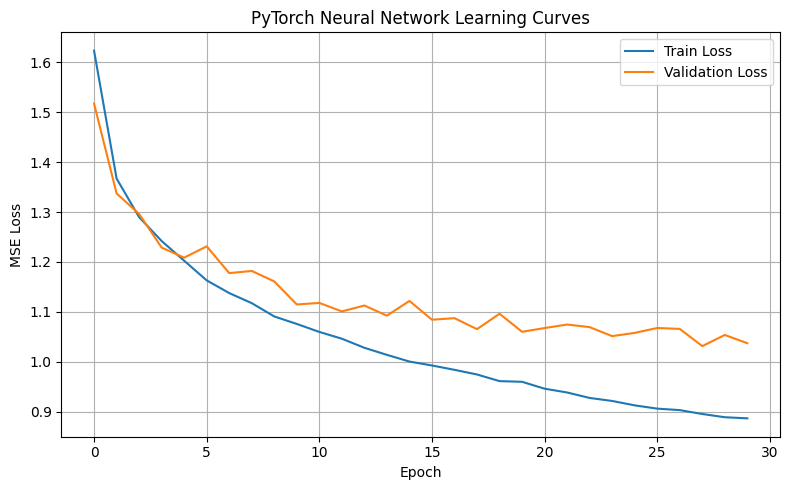


🔧 Training with 'spacegroup ' removed


Training Epochs:   3%|▎         | 1/30 [00:02<01:01,  2.12s/it]

Epoch   1 | Train Loss: 1.64600 | Val Loss: 1.46265


Training Epochs:  33%|███▎      | 10/30 [00:14<00:29,  1.49s/it]

Epoch  10 | Train Loss: 1.08315 | Val Loss: 1.12511


Training Epochs:  67%|██████▋   | 20/30 [00:28<00:14,  1.48s/it]

Epoch  20 | Train Loss: 0.96289 | Val Loss: 1.08266


Training Epochs: 100%|██████████| 30/30 [00:42<00:00,  1.41s/it]

Epoch  30 | Train Loss: 0.89608 | Val Loss: 1.05346


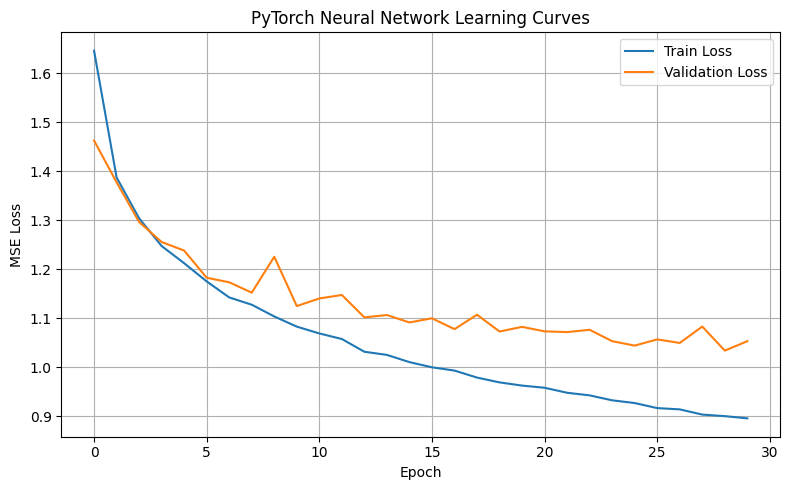

In [ ]:
experiment3_results = []

# With 'spacegroup '
print("\n🔧 Training with 'spacegroup ' included")
result_with, _, _ = train_torch_model(X_train_all, X_test_all, y_train_all, y_test_all, num_epochs=30, lr=1e-3)
result_with['Variant'] = "With 'spacegroup '"
experiment3_results.append(result_with)

# Without 'spacegroup '
print("\n🔧 Training with 'spacegroup ' removed")
result_without, _, _ = train_torch_model(X_train_drop, X_test_drop, y_train_all, y_test_all, num_epochs=30, lr=1e-3)
result_without['Variant'] = "Without 'spacegroup '"
experiment3_results.append(result_without)

### Result

In [ ]:
df_experiment3 = pd.DataFrame(experiment3_results)
df_experiment3 = df_experiment3[['Variant', 'Model', 'Test MAE', 'Test RMSE', 'Test R²']]
display(df_experiment3)


,Variant,Model,Test MAE,Test RMSE,Test R²
0,With 'spacegroup ',PyTorch DNN,0.762062,1.018446,0.570294
1,Without 'spacegroup ',PyTorch DNN,0.776380,1.026380,0.563573


**Conculsion**: The encoded `'spacegroup'` feature has a positive influence on the model performance.